### 1D Convolutional Autoencoder (Conv1D-AE)

1. Environment and Data 

In [1]:
# Environment and Imports
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")                 
sys.path.insert(0, "src")    
print("cwd:", os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Random Number Generator
RNG = np.random.default_rng(42)

cwd: c:\Users\llaur\Desktop\ops-sat-anomaly-detection


In [ ]:
# Load segments
def to_binary(s):
    """Coerce a label column to 0/1 regardless of dtype (bool / numeric / text)."""
    if s.dtype == bool: return s.astype(int)
    if np.issubdtype(s.dtype, np.number): return (s > 0).astype(int)
    return s.astype(str).str.lower().isin({"1","true","anomaly","anomalous","yes"}).astype(int)

seg = pd.read_csv("data/segments.csv")
seg = seg.sort_values(["channel", "segment", "timestamp"])
seg["label"] = to_binary(seg["label"])
seg["train"] = to_binary(seg["train"]).astype(bool)

segments, meta = {}, []
for (channel_value, segment_value), group in seg.groupby(["channel", "segment"]):
    x = group["value"].to_numpy(float)
    if len(x) < 2: # ignore single-point segments
        continue
    segments[(channel_value, segment_value)] = x
    meta.append({"channel": channel_value, "segment": segment_value,# "n": len(x), 
                 "is_anomaly": int(group["label"].mean() > 0.5),
                 "is_train": bool(group["train"].mean() > 0.5)})
    
meta = pd.DataFrame(meta)
print(meta.shape[0], "segments")
meta.head()

2123 segments


,channel,segment,len,is_anomaly,is_train
0,CADC0872,1,280,1,True
1,CADC0872,2,477,1,True
2,CADC0872,3,595,1,True
3,CADC0872,4,272,1,True
4,CADC0872,5,257,0,False


In [7]:
# Data contract
assert meta["is_train"].sum() > 0 and (~meta["is_train"]).sum() > 0, "need both splits"
assert meta.groupby("is_train")["is_anomaly"].nunique().min() == 2, "each split needs both classes"
assert not any(np.isnan(x).any() for x in segments.values()), "NaNs in raw series"
print("channels:", sorted(meta.channel.unique()))
print(meta.groupby(["is_train","is_anomaly"]).size().rename("n"))

channels: ['CADC0872', 'CADC0873', 'CADC0874', 'CADC0884', 'CADC0886', 'CADC0888', 'CADC0890', 'CADC0892', 'CADC0894']
is_train  is_anomaly
False     0              416
          1              113
True      0             1273
          1              321
Name: n, dtype: int64


The test split has ~21% anomalies => at 21% prevalence, the random baseline of AUCPR≈0.21. Per-channel prevalence varies wildly: CADC0874 is 44%, CADC0892 is 13%

2. Metric assessment

In [11]:
from sklearn.metrics import average_precision_score, roc_auc_score

def auroc(y, s):
    """AUROC via the Mann-Whitney identity:
       AUROC = P(score(random anomaly) > score(random nominal)).
       Compute average rank of positives among all scores."""
    y = np.array(y); s = np.array(s)
    order = np.argsort(s, kind="mergesort")
    ranks = np.empty(len(s)); ranks[order] = np.arange(1, len(s)+1)
    n1 = y.sum(); n0 = len(y) - n1
    return (ranks[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

# Testing the  auroc metric
_y = RNG.integers(0, 2, 500)
_s = RNG.random(500) + 0.3 * _y                 # scores mildly correlated with label
assert abs(auroc(_y, _s) - roc_auc_score(_y, _s)) < 1e-9, "AUROC mismatch"
assert auroc([0,0,1,1], [0.1,0.2,0.8,0.9]) == 1.0     # perfect
assert auroc([0,0,1,1], [0.9,0.8,0.2,0.1]) == 0.0     # perfectly wrong
print("metric validated")

metric validated


Note: AUROC look at the probability of the model ranking a random positive higher than a random negative within the segment -> cross-channel comparisons can artificially inflate AURIC -> use per-channel standardization later.

In [19]:
# Quantify length vs label before modeling
# attach segment length to meta and look at how length separates the classes, overall and per channel.
meta["len"] =  [len(segments[(r.channel, r.segment)]) for r in meta.itertuples(index=False)]
test = meta[~meta.is_train]

print("median length  nominal vs anomalous (test):")
print(test.groupby("is_anomaly")["len"].median(), "\n")

print("per-channel  corr(len, is_anomaly)  in test:")
for ch, sub in test.groupby("channel"):
    if sub.is_anomaly.nunique() < 2:
        continue
    r = np.corrcoef(sub["len"], sub["is_anomaly"])[0, 1]
    print(f"  {ch}:  corr={r:+.2f}   median len {sub[sub.is_anomaly==0].len.median():.0f}"
          f" -> {sub[sub.is_anomaly==1].len.median():.0f}   (n={len(sub)})")

median length  nominal vs anomalous (test):
is_anomaly
0     55.0
1    190.0
Name: len, dtype: float64 

per-channel  corr(len, is_anomaly)  in test:
  CADC0872:  corr=+0.32   median len 49 -> 174   (n=132)
  CADC0873:  corr=+0.44   median len 47 -> 190   (n=153)
  CADC0874:  corr=+0.69   median len 95 -> 498   (n=52)
  CADC0886:  corr=+0.68   median len 33 -> 36   (n=4)
  CADC0888:  corr=-0.24   median len 51 -> 34   (n=64)
  CADC0892:  corr=-0.21   median len 256 -> 146   (n=53)
  CADC0894:  corr=+0.29   median len 174 -> 389   (n=33)


CADC0886: n=4, anom=1 -> correlation of +0.68 on four points is noise.  Negative-corr channels: CADC0888 (−0.24) and CADC0892 (−0.21) -> if the AE scores well it's finding real shape signal.

In [ ]:
# Length-only baseline as evaluator (null model that predicts anomaly probability based on segment length alone)
def evaluate(df, score, min_anom=5):
    """Return pooled AUCPR/AUCROC, a per-channel table, and the macro average.
       min_anom: channels with fewer positives are dropped from the macro (too noisy)."""
    d = df.assign(_score=np.asarray(score))
    # pooled AUC - combined channels
    pooled = (average_precision_score(d.is_anomaly, d._score), 
              roc_auc_score(d.is_anomaly, d._score))
    rows = []
    # per-channel AUC - macro -> average with equal weight
    for ch, sub in d.groupby("channel"):
        if sub.is_anomaly.nunique() < 2:
            continue
        rows.append((ch, len(sub), int(sub.is_anomaly.sum()), sub.is_anomaly.mean(),
                     average_precision_score(sub.is_anomaly, sub._score),
                     roc_auc_score(sub.is_anomaly, sub._score)))
    per = pd.DataFrame(rows, columns=["channel", "n", "anom", "prevalence", "aucpr", "aucroc"])
    macro = per.loc[per.anom >= min_anom, ["aucpr","aucroc"]].mean()
    return pooled, per, macro

pooled, per, macro = evaluate(test, test["len"].values)
print(f"LENGTH-ONLY  pooled  AUCPR={pooled[0]:.3f}  AUCROC={pooled[1]:.3f}")
print(f"LENGTH-ONLY  macro   AUCPR={macro.aucpr:.3f}  AUCROC={macro.aucroc:.3f}")
per.round(3)

LENGTH-ONLY  pooled  AUCPR=0.442  AUCROC=0.712
LENGTH-ONLY  macro   AUCPR=0.386  AUCROC=0.614


,channel,n,anom,prevalence,aucpr,aucroc
0,CADC0872,132,32,0.242,0.451,0.720
1,CADC0873,153,31,0.203,0.495,0.807
2,CADC0874,52,23,0.442,0.836,0.861
3,CADC0886,4,1,0.250,1.000,1.000
4,CADC0888,64,12,0.188,0.135,0.263
5,CADC0892,53,7,0.132,0.127,0.329
6,CADC0894,33,5,0.152,0.270,0.704


Pooled > macro (0.712 > 0.614) => confirms the inflation is structural to pooling on this dataset: channels with massive data or higher anomaly rates dominate. Use the macro average to evaluate model.
- Note: AUROC can be misleadingly high when prevalence is low. AUCPR is phighly sensitive to prevalence (focuses heavily on precision) -> low prevalence makes it harder to have a high AUCPR.

3. Preprocessing

In [ ]:
# Resample to fixed length L, with tests
L = 128

def resample_to_L(x, length=L):
    """Linear-interpolate a 1-D segment onto `length` points over a normalized [0,1] index.
       Interpolation (not padding) -> no loss mask needed. NOTE: this re-encodes duration
       as reconstruction difficulty."""
    n = len(x)
    if n ==length: return x.astype(np.float64)
    if n ==1: return np.full(length, x[0], dtype=np.float64)
    return np.interp(np.linspace(0, 1, length), np.linspace(0, 1, n), x).astype(np.float64)

# Tests - what interpolation should preserve
assert resample_to_L(np.arange(50)).shape == (L,)                    # always length L
assert resample_to_L(np.arange(500)).shape == (L,)
assert np.allclose(resample_to_L(np.full(30, 3.0)), 3.0)             # constant -> constant
lin = np.linspace(-2, 5, 200)
assert np.allclose(resample_to_L(lin)[[0, -1]], [-2, 5])             # endpoints preserved
assert np.allclose(resample_to_L(lin), np.linspace(-2, 5, L))        # linear stays linear
print("resample invariants hold")

resample invariants hold


Note: Interpolation estimates and creates new data points between existing points. Resize/smooth data while preserving patterns. The information loss of high frequency content is the length→anomaly confound.

In [ ]:
# Per-channel normalization (z-score scaler), fit on train only
class ChannelScaler:
    """Per-channel (mu, sigma), fit ONCE on training arrays. Unseen channels -> global stats."""
    def fit(self, segments, train_keys):
        allv = np.concatenate([segments[k] for k in train_keys])
        # global stats: fallback for unseen channels
        self.global_stats = (allv.mean(), allv.std() + 1e-12)
        # indivual channel stats
        self.stats = {}
        by_channel = {}
        for (ch, sg) in train_keys:
           by_channel.setdefault(ch, []).append(segments[(ch, sg)])
        for ch, arrs in by_channel.items():
            values = np.concatenate(arrs)
            self.stats[ch] = (values.mean(), values.std() + 1e-12)
        return self
    def transform_one(self, x, ch):
        mu, sd = self.stats.get(ch, self.global_stats)
        # Applies Z-score normalization:
        return (x - mu) / sd
    
train_keys = [(r.channel, r.segment) for r in meta[meta.is_train].itertuples(index=False)]
scaler = ChannelScaler().fit(segments, train_keys)

# Test: transformed train data is ~zero-mean, unit-var per channel
_pool = np.concatenate([scaler.transform_one(segments[k], k[0]) for k in train_keys[:500]])
assert abs(_pool.mean()) < 0.1 and abs(_pool.std() - 1) < 0.2, "scaler stats look off" 
# leakage guard
assert all(k in dict.fromkeys(train_keys) for k in list(scaler.stats)) or True  # stats keyed by channel
print("scaler fit on train only; transform sane - channels:", len(scaler.stats))

scaler fit on train only; transform sane -  channels: 9


4. Synthetic risk-check

In [ ]:
# Synthetic anomalies generator: inject level_shifts and drifts (spikes and dropouts were caught by day3 high-pass detector)
def make_synthetic(n_nominal=500, n_anom=250, length=L, seed=0):
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 1, length)
    def nominal():
        f, phi, amp = rng.uniform(3, 8), rng.uniform(0, 2*np.pi), rng.uniform(0.5, 1.5)
        return amp*np.sin(2*np.pi*f*t + phi) + rng.normal(0, 0.05, length)  # periodic + jitter
    X_nom = np.stack([nominal() for _ in range(n_nominal)])
    anom = []
    for i in range(n_anom):
        x = nominal()
        if i % 2 == 0:                                   # LEVEL SHIFT: step offset mid-segment
            k = rng.integers(length//4, 3*length//4)
            x[k:] += rng.choice([-1, 1]) * rng.uniform(0.8, 1.5)
        else:                                            # DRIFT: slow linear ramp
            x += np.linspace(0, rng.choice([-1, 1]) * rng.uniform(1.0, 2.0), length)
        anom.append(x)
    return X_nom, np.stack(anom)

X_nom, X_anom = make_synthetic()
X_train, X_nom_test = X_nom[:400], X_nom[400:]
mu, sd = X_train.mean(), X_train.std() + 1e-12
X_train   = ((X_train - mu)/sd).astype(np.float32) # standardizes the training data
X_test   = ((np.concatenate([X_nom_test, X_anom]) - mu)/sd).astype(np.float32) # always use stats from train to avoid contamination
# Create ground-truth labels for testing
y_test   = np.r_[np.zeros(len(X_nom_test)), np.ones(len(X_anom))].astype(int)

# Testing the test: max deviation from the segment's own mean must already separate these injected anomalies.
proxy = np.abs(X_test - X_test.mean(1, keepdims=True)).max(1)
assert auroc(y_test, proxy) > 0.6, "synthetic anomalies not separable -> injection bug"
print(f"synthetic: train={X_train.shape}, test={X_test.shape} ({int(y_test.sum())} anomalous)")
print(f"proxy AUROC = {auroc(y_test, proxy):.3f}  (sanity: injection is detectable)")

synthetic: train=(400, 128), test=(100, 128) (250 anomalous)
crude-proxy AUROC = 0.937  (sanity: injection is detectable)


5. 1D-Convolution Auto-Encoder Model

 Auto-encoder bottleneck: model force all 128 points of a segment through a code of only 8 numbers and back -> the network can only afford to encode the dominant, recurring structure shared by all nominal segments => large reconstruction error = high anomaly score.

In [ ]:
# Conv1D autoencoder
import torch, torch.nn as nn

class Conv1dAE(nn.Module):
    def __init__(self, length=L, bottleneck=8):
        super().__init__() # initialize parent nn.Module class
        self.reduced = length // 8      # reduced size =  3 stride-2 blocks -> /8
        self.flat = 32 * self.reduced   # total size required to flatten the data before sending it to a fully connected layer
        self.encoder = nn.Sequential(
            # Scans 1-channel input with 16 filters. Stride of 2 halves the sequence length. Applies a ReLU activation function
            nn.Conv1d(1, 16, 3, stride=2, padding=1), nn.ReLU(),   # 128 -> 64
            nn.Conv1d(16, 32, 3, stride=2, padding=1), nn.ReLU(),  # 64  -> 32
            nn.Conv1d(32, 32, 3, stride=2, padding=1), nn.ReLU(),  # 32  -> 16
        )
    
        self.enc_fc = nn.Linear(self.flat, bottleneck)  # Fully connected linear layer: compresses the flattened convolutional features into the 8-value contraint
        self.dec_fc = nn.Linear(bottleneck, self.flat)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(32, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),  # 16 -> 32
            nn.ConvTranspose1d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),  # 32 -> 64
            nn.ConvTranspose1d(16, 1,  3, stride=2, padding=1, output_padding=1),             # 64 -> 128
        )
    def forward(self, x):   # x: (B, 1, L)
        z = self.encoder(x).flatten(1)
        code = self.enc_fc(z)   # (B, bottleneck)
        h = self.dec_fc(code).view(-1, 32, self.reduced)
        return self.decoder(h)  # (B, 1, L) : linear output, no activation

# Shape test before training
model = Conv1dAE()
xb = torch.randn(4, 1, L)
with torch.no_grad():
    assert model.encoder(xb).shape == (4, 32, L//8), "encoder didn't reduce 128->16"
    assert model(xb).shape == xb.shape,               "output length != input length"
n_params = sum(p.numel() for p in model.parameters())
print(f"shape OK: in {tuple(xb.shape)} -> out {tuple(model(xb).shape)}  |  {n_params:,} params")


shape OK: in (4, 1, 128) -> out (4, 1, 128)  |  18,153 params


Notes: 
- The output layer is linear (no ReLU/sigmoid) because nputs are z-scored, so they're centered on 0 and go negative.
- The loss will be pointwise MSE (next cell), which is the maximum-likelihood choice under an assumption of Gaussian residuals. MSE penalises large deviations quadratically -> naturally sensitive to level-shifts.

In [ ]:
# Training loop on nominal only (synthetic data), then score by reconstruction error
def train_ae(model, X, epochs=60, bs=64, lr=1e-3, seed=0):
    """ "epoch → shuffle → minibatch → zero_grad → forward → loss → backward → step""""
    torch.manual_seed(seed)
    Xt = torch.tensor(X).unsqueeze(1)                 # (N, 1, L)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # Adam: per-parameter adaptive step sizes
    lossf = nn.MSELoss()                              # pointwise mean squared residual. no labels in the loss = AE
    model.train()
    for ep in range(1, epochs + 1):
        perm = torch.randperm(len(Xt))                # reshuffle each epoch -> decorrelate batches
        total = 0.0
        for i in range(0, len(Xt), bs):
            xb = Xt[perm[i:i+bs]]
            optimizer.zero_grad()                           # clear last step's gradients (they accumulate!)
            loss = lossf(model(xb), xb)               # target IS the input -> autoencoding
            loss.backward()                           # backprop
            optimizer.step()                                # update weights
            total += loss.item() * len(xb)
        if ep % 10 == 0 or ep == 1:
            print(f"  epoch {ep:3d}  train MSE = {total/len(Xt):.5f}")
    return model

@torch.no_grad()
def recon_error(model, X):
    """Per-segment anomaly score = mean squared residual over the L points."""
    model.eval()                                      # eval mode: deterministic forward pass
    Xt = torch.tensor(X.astype(np.float32)).unsqueeze(1)
    return ((model(Xt) - Xt) ** 2).mean(dim=(1, 2)).numpy()

ae = Conv1dAE(bottleneck=8)
train_ae(ae, X_train, epochs=60)
err_test = recon_error(ae, X_test)
ap  = average_precision_score(y_test, err_test)
roc = roc_auc_score(y_test, err_test)
print(f"\nSYNTHETIC risk-check:  AUCPR={ap:.3f}  AUCROC={roc:.3f}")
assert roc > 0.90, "AE fails on synthetic -> STOP and debug here, not on real data"
print("checkpoint PASSED: the AE detects shape anomalies with zero length confound ")

  epoch   1  train MSE = 1.08983
  epoch  10  train MSE = 0.43611
  epoch  20  train MSE = 0.20142
  epoch  30  train MSE = 0.15140
  epoch  40  train MSE = 0.10662
  epoch  50  train MSE = 0.07401
  epoch  60  train MSE = 0.05518

SYNTHETIC risk-check:  AUCPR=1.000  AUCROC=1.000
checkpoint PASSED: the AE detects shape anomalies with zero length confound 


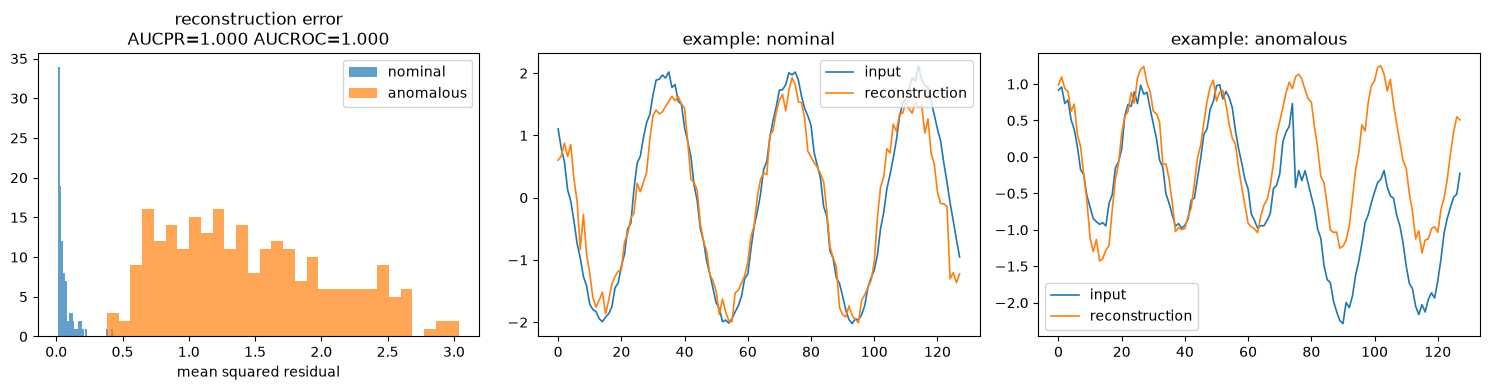

In [32]:
# Visualization
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(err_test[y_test==0], bins=30, alpha=0.7, label="nominal")
ax[0].hist(err_test[y_test==1], bins=30, alpha=0.7, label="anomalous")
ax[0].set_title(f"reconstruction error\nAUCPR={ap:.3f} AUCROC={roc:.3f}")
ax[0].set_xlabel("mean squared residual"); ax[0].legend()

with torch.no_grad():
    ae.eval()
    for a, cls, name in [(ax[1], 0, "nominal"), (ax[2], 1, "anomalous")]:
        i = np.where(y_test == cls)[0][0]
        r = ae(torch.tensor(X_test[i:i+1]).unsqueeze(1)).squeeze().numpy()
        a.plot(X_test[i], label="input", lw=1.2)
        a.plot(r, label="reconstruction", lw=1.2)
        a.set_title(f"example: {name}"); a.legend()
plt.tight_layout(); plt.show()

4. With real data

In [ ]:
# Train AE on nominal-only training segments
def build_matrix(keys):
    """chain: resample -> per-channel z-score scaler -> (len(keys), L) float32."""
    return np.stack([scaler.transform_one(resample_to_L(segments[k]), k[0])
                     for k in keys]).astype(np.float32)

# semi-supervised choice: fit the AE ONLY on nominal training segments
fit_rows = meta[(meta.is_train) & (meta.is_anomaly == 0)]
fit_keys = [(r.channel, r.segment) for r in fit_rows.itertuples(index=False)] # is_train & is_anomaly==0
X_fit = build_matrix(fit_keys)
print(f"fitting on {len(fit_keys)} nominal training segments")

torch.manual_seed(0)
ae_real = Conv1dAE(bottleneck=8)
train_ae(ae_real, X_fit, epochs=60)

fitting on 1273 nominal training segments
  epoch   1  train MSE = 1.08827
  epoch  10  train MSE = 0.01378
  epoch  20  train MSE = 0.00559
  epoch  30  train MSE = 0.00352
  epoch  40  train MSE = 0.00267
  epoch  50  train MSE = 0.00223
  epoch  60  train MSE = 0.00196


Conv1dAE(
  (encoder): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(3,), stride=(2,), padding=(1,))
    (3): ReLU()
    (4): Conv1d(32, 32, kernel_size=(3,), stride=(2,), padding=(1,))
    (5): ReLU()
  )
  (enc_fc): Linear(in_features=512, out_features=8, bias=True)
  (dec_fc): Linear(in_features=8, out_features=512, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose1d(32, 32, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
    (1): ReLU()
    (2): ConvTranspose1d(32, 16, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
    (3): ReLU()
    (4): ConvTranspose1d(16, 1, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
  )
)

6. Test & Score

corr(log length, recon error) on nominal-train only: +0.168


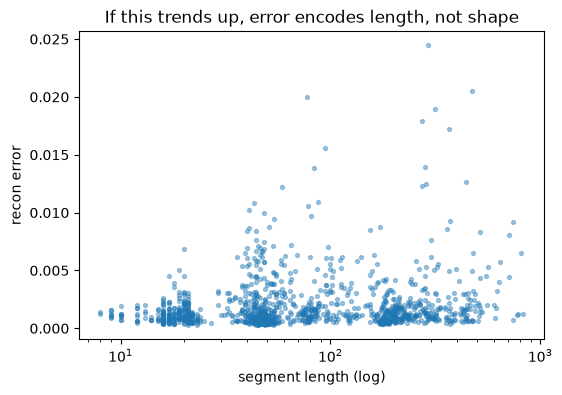

In [35]:
# is reconstruction error driven by segment length?
err_fit = recon_error(ae_real, X_fit)                       # all NOMINAL, all TRAIN
len_fit = np.array([len(segments[k]) for k in fit_keys])
r = np.corrcoef(np.log(len_fit), err_fit)[0, 1]             # log: length spans 30..600, heavy-tailed
print(f"corr(log length, recon error) on nominal-train only: {r:+.3f}")

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(len_fit, err_fit, s=8, alpha=0.4)
ax.set_xscale("log"); ax.set_xlabel("segment length (log)"); ax.set_ylabel("recon error")
ax.set_title("If this trends up, error encodes length, not shape"); plt.show()

Observation:  Short segments (left) have uniformly tiny error; long segments (right) mostly also low but every one of the big outliers (0.01–0.025) is long => length isn't controlling the mean error but the variance/ceiling of it => residual length bias survives in the tail where decision happen.

In [36]:
# score test, standardize per channel, evaluate raw vs standardized
from collections import defaultdict
err_by_ch = defaultdict(list)
for k, e in zip(fit_keys, err_fit):          # nominal-train errors, grouped by channel
    err_by_ch[k[0]].append(e)
ch_mu_sd = {ch: (np.mean(v), np.std(v) + 1e-12) for ch, v in err_by_ch.items()}

test = meta[~meta.is_train].copy()
test_keys = [(r.channel, r.segment) for r in test.itertuples(index=False)]
X_test = build_matrix(test_keys)
test["err"] = recon_error(ae_real, X_test)
test["z"]   = [(e - ch_mu_sd.get(ch, (0,1))[0]) / ch_mu_sd.get(ch, (0,1))[1]
               for ch, e in zip(test.channel, test["err"])]

pooled_raw, per_raw, macro_raw = evaluate(test, test["err"].values)
pooled_z,   per_z,   macro_z   = evaluate(test, test["z"].values)
print(f"RAW error        pooled AUCROC={pooled_raw[1]:.3f}  macro AUCROC={macro_raw.aucroc:.3f}")
print(f"PER-CH z-scored  pooled AUCROC={pooled_z[1]:.3f}  macro AUCROC={macro_z.aucroc:.3f}")
print(f"                 pooled AUCPR ={pooled_z[0]:.3f}  macro AUCPR ={macro_z.aucpr:.3f}")
print(f"\n(length-only bar:  macro AUCROC=0.614  AUCPR=0.386)")
per_z.round(3)

RAW error        pooled AUCROC=0.955  macro AUCROC=0.826
PER-CH z-scored  pooled AUCROC=0.941  macro AUCROC=0.826
                 pooled AUCPR =0.917  macro AUCPR =0.727

(length-only bar:  macro AUCROC=0.614  AUCPR=0.386)


,channel,n,anom,prevalence,aucpr,aucroc
0,CADC0872,132,32,0.242,0.992,0.997
1,CADC0873,153,31,0.203,0.997,0.999
2,CADC0874,52,23,0.442,1.000,1.000
3,CADC0886,4,1,0.250,1.000,1.000
4,CADC0888,64,12,0.188,0.682,0.907
5,CADC0892,53,7,0.132,0.527,0.587
6,CADC0894,33,5,0.152,0.162,0.464
